### Problem Statement
You are working as a Data Analyst in a financial institution. The company wants to build a model to predict
whether a loan application will be approved (1) or not approved (0) based on customer details.

Your task is to perform Exploratory Data Analysis (EDA), build a Logistic Regression model, evaluate the model,
and interpret the results.

### Dataset Link: [Loan Approval Prediction](https://docs.google.com/spreadsheets/d/1xlCse4pfSunm2t3cH0XA3UKcl8ecmWNbfQHFqw-dzvg/edit?gid=1685199381#gid=1685199381)

### Q1. Data loading & Understanding
1. Load the dataset into python
2. Display the first 5 rows
3. Check the shape of the dataset
4. Display the data types of each column.

In [4]:
# Solution

# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload csv file
from google.colab import files
uploaded = files.upload()

# Loading the dataset
df = pd.read_csv('loan_approval - loan_approval.csv')

# Display first 5 rows
print("Displaying first 5 rows:")
display(df.head())

# Check the shape of the dataset
print("\nChecking the shape of the dataset: ", df.shape)

# Display the data types of each column
print("\nDisplaying the data types of each column: ")
print(df.dtypes)

# Display basic information of dataset
print("\nDisplaying basic information of dataset:")
df.info()

Saving loan_approval - loan_approval.csv to loan_approval - loan_approval (3).csv
Displaying first 5 rows:


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False



Checking the shape of the dataset:  (2000, 8)

Displaying the data types of each column: 
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

Displaying basic information of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


### Q2. Data Cleaning
1. Check for missing values in the dataset
2. Handle missing values appropriately.
3. Identify categorical columns present in the dataset.

In [5]:
# Solution part 1

print("Checking for missing values in the dataset:")
print(df.isnull().sum())

Checking for missing values in the dataset:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


#### Solution part 2
Since there are no missing values so no need to handle them but if there were we would handle them using below code:

```
# Numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill numerical missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Fill categorical missing values with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after treatment:")
print(df.isnull().sum())
```

In [7]:
# Solution part 3

print("Identifying categorical columns present in the dataset:")
categorical_columns = df.select_dtypes(include='object').columns
print(categorical_columns.to_list())

Identifying categorical columns present in the dataset:
['name', 'city']


### Q3. Exploratory Data Analysis (EDA)
1. Plot the distribution of the target variable.
2. Analyze the relationship between one numerical feature and the target variable.
3. Analyze the relationship between Years of Employment and the target variable.

loan_approved
False    1121
True      879
Name: count, dtype: int64


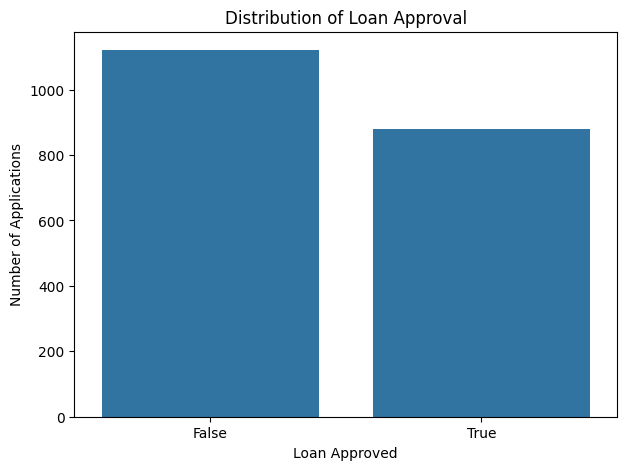

In [8]:
# Solution part 1

print(df['loan_approved'].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='loan_approved'
)

plt.title('Distribution of Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Number of Applications')

plt.show()

**Interpretation**

There are:

- 1,121 applications not approved
- 879 applications approved

The target classes are reasonably represented, although there are somewhat more rejected applications.

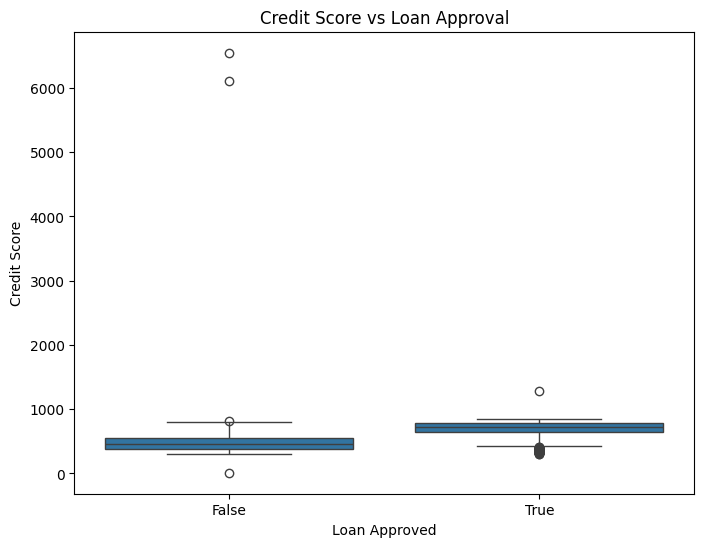

loan_approved
False    482.107939
True     704.403868
Name: credit_score, dtype: float64


In [10]:
# Solution part 2

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='loan_approved',
    y='credit_score'
)

plt.title('Credit Score vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Credit Score')

plt.show()

print(
    df.groupby('loan_approved')['credit_score'].mean()
)

**Interpretation**

Approved applications have a substantially higher average credit score than rejected applications.

This suggests that credit score is an important predictor of loan approval in this dataset.

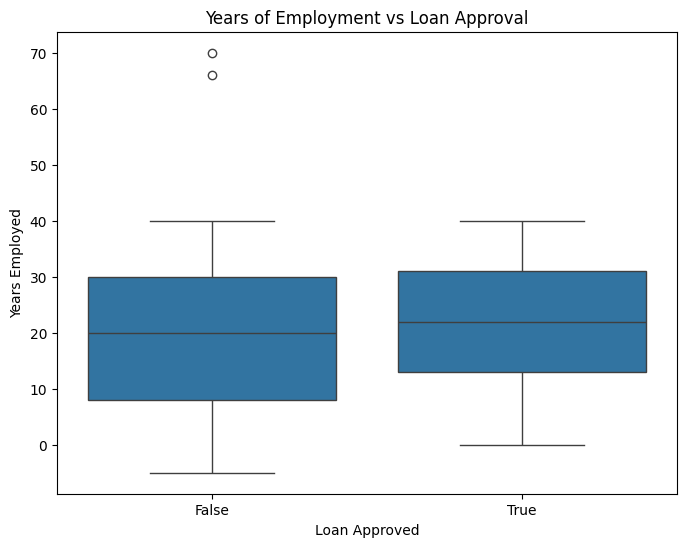

loan_approved
False    19.425513
True     21.829352
Name: years_employed, dtype: float64


In [11]:
# Solution part 3

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='loan_approved',
    y='years_employed'
)

plt.title('Years of Employment vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Years Employed')

plt.show()

print(
    df.groupby('loan_approved')['years_employed'].mean()
)

**Interpretation**

Approved applicants have a somewhat higher average employment duration.

However, the difference is smaller than the observed difference in credit score or points.

### Q4. Outlier Detection and Treatment
1. Detect outliers in numerical columns using the IQR method.
2. Treat outliers using capping techniques.

In [12]:
# Solution part 1

numerical_columns = [
    'income',
    'credit_score',
    'loan_amount',
    'years_employed',
    'points'
]

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\nColumn: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


Column: income
Q1: 61296.25
Q3: 120099.75
IQR: 58803.5
Lower Bound: -26909.0
Upper Bound: 208305.0
Number of Outliers: 0

Column: credit_score
Q1: 433.0
Q3: 716.0
IQR: 283.0
Lower Bound: 8.5
Upper Bound: 1140.5
Number of Outliers: 3

Column: loan_amount
Q1: 12748.75
Q3: 37380.5
IQR: 24631.75
Lower Bound: -24198.875
Upper Bound: 74328.125
Number of Outliers: 0

Column: years_employed
Q1: 10.0
Q3: 31.0
IQR: 21.0
Lower Bound: -21.5
Upper Bound: 62.5
Number of Outliers: 2

Column: points
Q1: 45.0
Q3: 70.0
IQR: 25.0
Lower Bound: 7.5
Upper Bound: 107.5
Number of Outliers: 0


**Important Results**

| Column | Outliers |
| ------ | -------- |
| income | 0 |
| credit_score | 3 |
| loan_amount | 0 |
| years_employed | 2 |
| points | 0 |

Therefore outliers are present mainly in credit_score and years_employed.

In [13]:
# Solution part 2

df_clean = df.copy()

for col in numerical_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping
    df_clean[col] = df_clean[col].clip(
        lower_bound,
        upper_bound
    )

print("Outlier treatment completed.")

Outlier treatment completed.


| Feature | Lower Bound | Upper Bound |
| ---- | ---- | ---- |
| income | -26,909 | 208,305 |
| credit_score | 8.5 | 1,140.5 |
| loan_amount | -24,198.875 | 74,328.125|
| years_employed | -21.5 | 62.5 |
| points | 7.5 | 107.5 |

**Interpretation**

Capping replaces values beyond the IQR limits with the corresponding lower or upper boundary instead of deleting the records.

This preserves all 2,000 observations.

### Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [14]:
# Solution

# Convert target to numerical format
df_clean['loan_approved'] = (
    df_clean['loan_approved'].astype(int)
)

# Drop unnecessary categorical columns
df_clean = df_clean.drop(
    columns=['name', 'city']
)

print("Final columns:")
print(df_clean.columns.tolist())

print("\nFirst 5 rows:")
display(df_clean.head())

Final columns:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved']

First 5 rows:


,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,0
1,44592,729.0,15446,28.0,55,0
2,33278,584.0,11189,13.0,45,0
3,127196,344.0,48823,29.0,50,0
4,66048,496.0,47174,4.0,25,0


### Q6. Feature Selection and Data Splitting.
1. Separate independent variables (X) and dependent variable (Y).
2. Split the dataset into training and testing sets.

In [15]:
# Solution part 1

X = df_clean[
    [
        'income',
        'credit_score',
        'loan_amount',
        'years_employed',
        'points'
    ]
]

y = df_clean['loan_approved']

print("Independent variables (X):")
display(X.head())

print("\nDependent variable (y):")
display(y.head())

Independent variables (X):


,income,credit_score,loan_amount,years_employed,points
0,113810,389.0,39698,27.0,50
1,44592,729.0,15446,28.0,55
2,33278,584.0,11189,13.0,45
3,127196,344.0,48823,29.0,50
4,66048,496.0,47174,4.0,25



Dependent variable (y):


,loan_approved
0,0
1,0
2,0
3,0
4,0


In [16]:
# Solution part 2

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

print("\nTraining target shape:")
print(y_train.shape)

print("\nTesting target shape:")
print(y_test.shape)

Training data shape:
(1600, 5)

Testing data shape:
(400, 5)

Training target shape:
(1600,)

Testing target shape:
(400,)


Thus:
- Training records = 1600
- Testing records = 400

### Q7. Apply feature scaling to the dataset using StandardScaler.

Standardization uses:

$$ z=\frac{x-\mu}{\sigma} $$

where:

- x = original value
- μ = mean
- σ = standard deviation

In [17]:
# Solution

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:")
print(X_train_scaled[:5])

print("\nScaled testing data:")
print(X_test_scaled[:5])

Scaled training data:
[[-0.17342933  0.47850982  0.03478074 -1.14858773 -0.1017349 ]
 [-0.22960205  0.77983528 -1.22829888  1.3855275   1.25699495]
 [ 0.4646404  -0.56075553  0.36246017  1.46999801 -0.37348087]
 [-0.76117645  1.02581524 -0.84514756  1.3855275   1.25699495]
 [ 1.06164292  1.65306415 -1.23690902 -0.30388265  2.34397883]]

Scaled testing data:
[[ 0.2652709   0.49080882  1.53485099 -0.13494164  0.17001107]
 [-0.82168583 -0.67144651  0.09265219  0.37188141 -1.18871878]
 [-1.57937726  1.61616716 -0.69390547 -0.8107057   0.44175704]
 [ 0.42595981  0.75523728  0.49556449  1.21658649  0.98524898]
 [-1.0786251  -0.15488859  1.53223972  1.21658649 -1.18871878]]


### Q8. Logistic Regression Model Building.
1. Train a Logistic Regression model.
2. Predict the output for test data.

In [18]:
# Solution part 1

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
# Solution part 2

# Class prediction
y_pred = model.predict(X_test_scaled)

# Probability prediction
y_pred_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predicted classes:")
print(y_pred[:20])

print("\nPredicted probabilities:")
print(y_pred_probability[:20])

Predicted classes:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]

Predicted probabilities:
[7.71071761e-01 2.28948757e-06 9.94590445e-01 9.99956713e-01
 2.18862902e-06 1.00000000e+00 9.82318023e-03 9.99998630e-01
 1.30136277e-01 2.17204433e-06 9.91901788e-01 2.57897174e-06
 9.99299906e-01 6.47478200e-04 9.99999899e-01 9.99939881e-01
 2.02216170e-05 9.99999850e-01 9.75010595e-09 4.62969157e-05]


### Q9. Model Evaluation - Confusion Matrix
1. Generate the confusion matrix
2. Interpret the results.

Confusion Matrix:


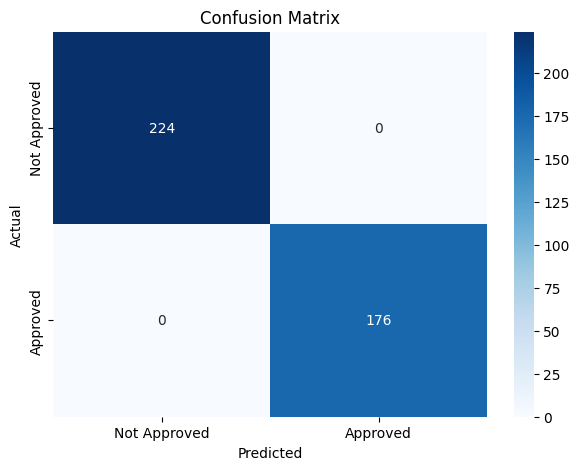

In [22]:
# Solution part 1

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")

# Upon Visualizing
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Approved', 'Approved'],
    yticklabels=['Not Approved', 'Approved']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

#### Solution part 2

The confusion matrix is:

$$ \begin{bmatrix} 224 & 0\\ 0 & 176 \end{bmatrix} $$

Therefore:

|	|Predicted 0	|Predicted 1|
| --- | --- | --- |
|Actual 0	|224|	0|
|Actual 1|	0|	176|

Where:

- True Negative = 224
- False Positive = 0
- False Negative = 0
- True Positive = 176

**Interpretation**

The model correctly classified all 224 test cases belonging to class 0 and all 176 test cases belonging to class 1 for this particular train/test split.

Therefore, the test set contains:
- 400 total observations
- 400 correctly classified
- 0 incorrectly classified

### Q10. Model Evaluation - ROC Curves & AUC
1. Plot the ROC curve
2. Calculate the AUC score.

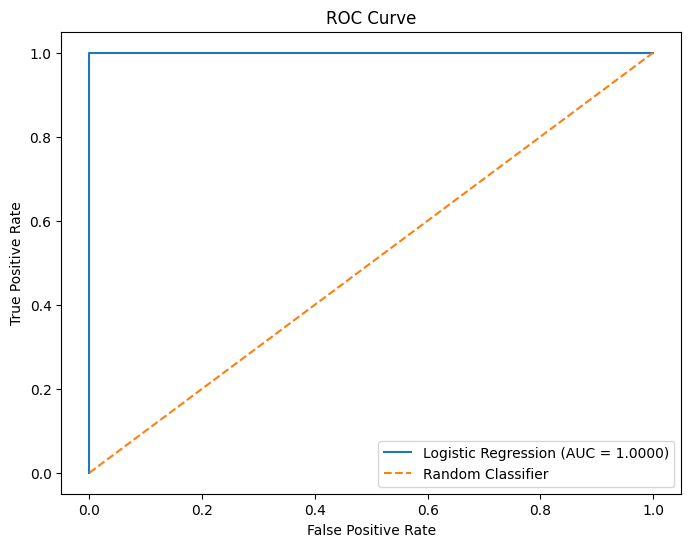

In [24]:
# Solution part 1

from sklearn.metrics import roc_curve, roc_auc_score

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

# Calculate AUC
auc_score = roc_auc_score(
    y_test,
    y_pred_probability
)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.4f})'
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [25]:
# Solution part 2

print("AUC Score:", auc_score)

AUC Score: 1.0


**Interpretation**

An AUC of 1.0 means that, on this particular test split, the model perfectly separated the approved and not-approved applications.

The ROC curve therefore reaches the ideal top-left region.